<a href="https://colab.research.google.com/github/GeorgiosKoutris/Cloud-Platforms-and-Architectures-Work/blob/main/%CE%A0%CE%BB%CE%B1%CF%84%CF%86%CF%8C%CF%81%CE%BC%CE%B5%CF%82_%CE%BA%CE%B1%CE%B9_%CE%91%CF%81%CF%87%CE%B9%CF%84%CE%B5%CE%BA%CF%84%CE%BF%CE%BD%CE%B9%CE%BA%CE%AD%CF%82_%CE%9D%CE%AD%CF%86%CE%BF%CF%85%CF%82_%CE%95%CF%81%CE%B3%CE%B1%CF%83%CE%AF%CE%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark matplotlib

#### Κελί 2: Εκτέλεση Πειράματος & Δημιουργία Γραφημάτων


[1/2] Εκτέλεση: Single-Node Python MapReduce...
-> Single-Node Python Time: 9.58 sec
-> Συνολικές μοναδικές λέξεις: 61

[2/2] Εκτέλεση: Apache Spark RDD (PySpark Engine)...
-> Apache Spark Time: 23.28 sec
-> Συνολικές μοναδικές λέξεις: 61


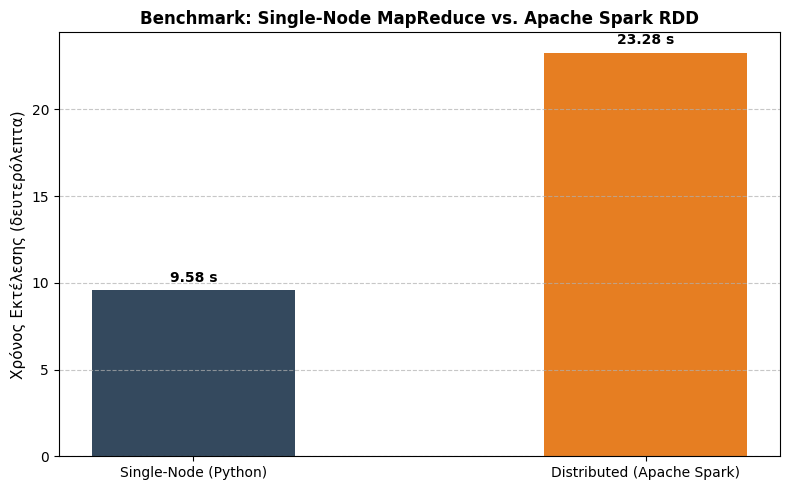


--- Συγκριτικά Αποτελέσματα για τον Πίνακα της Εργασίας ---
Μέθοδος 1 (Python Single-Node): 9.58 s
Μέθοδος 2 (Apache Spark RDD):    23.28 s
Speedup / Διαφορά Απόδοσης:     0.41x
Το διάγραμμα αποθηκεύτηκε ως 'spark_vs_python_benchmark.png'.


In [ ]:
import os
import time
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

DATA_FILE = "input_text.txt"

# 1. Αυτόματη δημιουργία πραγματικού μεγάλου όγκου κειμένου για το benchmarking
if not os.path.exists(DATA_FILE):
  print("Δημιουργία αρχείου κειμένου για το benchmark...")
  sample_text = """
    Apache Spark is a unified analytics engine for large scale data processing.
    It provides high-level APIs in Java Scala Python and R and an optimized engine.
    Spark runs on both Windows and UNIX-like systems such as Linux and Mac OS.
    MapReduce is a processing technique and a program model for distributed computing.
    The major advantage of MapReduce is that it is easy to scale data processing over multiple nodes.
    Cloud platforms enable scalable storage and distributed computation across clusters.
    """
  # Επαναλαμβάνουμε το κείμενο ώστε να δημιουργηθεί ένα αρχείο μερικών εκατοντάδων χιλιάδων γραμμών
  with open(DATA_FILE, "w", encoding="utf-8") as f:
    for _ in range(250000):
      f.write(sample_text)
  print(
      f"Το αρχείο {DATA_FILE} δημιουργήθηκε με επιτυχία (Μέγεθος: ~"
      f"{os.path.getsize(DATA_FILE) / (1024*1024):.1f} MB)."
  )

# Baseline Single-Node MapReduce (Python)

print("\n[1/2] Εκτέλεση: Single-Node Python MapReduce...")
t0_py = time.time()

word_counts_py = {}
with open(DATA_FILE, "r", encoding="utf-8") as f:
  for line in f:
    # Map Phase: Tokenization & Key-Value generation
    words = line.strip().split()
    for word in words:
      clean_word = word.lower()
      # Reduce Phase: Aggregation
      word_counts_py[clean_word] = word_counts_py.get(clean_word, 0) + 1

py_duration = time.time() - t0_py
print(f"-> Single-Node Python Time: {py_duration:.2f} sec")
print(f"-> Συνολικές μοναδικές λέξεις: {len(word_counts_py)}")

# Εκτέλεση με Apache Spark RDD

print("\n[2/2] Εκτέλεση: Apache Spark RDD (PySpark Engine)...")
t0_spark = time.time()

# Αρχικοποίηση Spark Context χρησιμοποιώντας όλους τους πυρήνες
spark = (
    SparkSession.builder.appName("SparkBasicsBenchmark")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
sc = spark.sparkContext

# Ροή Εκτέλεσης: Ανάγνωση, Μετασχηματισμός και Αναγωγή Δεδομένων
lines = sc.textFile(DATA_FILE)
counts = (
    lines.flatMap(lambda line: line.strip().split())
    .map(lambda word: (word.lower(), 1))
    .reduceByKey(lambda a, b: a + b)
)

# Action: Trigger execution & συλλογή αποτελεσμάτων
output = counts.collect()

spark_duration = time.time() - t0_spark
print(f"-> Apache Spark Time: {spark_duration:.2f} sec")
print(f"-> Συνολικές μοναδικές λέξεις: {len(output)}")

# Τερματισμός Spark Session
spark.stop()

# ΠΑΡΑΓΩΓΗ ΓΡΑΦΗΜΑΤΟΣ & ΠΙΝΑΚΑ ΓΙΑ ΤΗΝ ΑΝΑΦΟΡΑ

methods = ["Single-Node (Python)", "Distributed (Apache Spark)"]
times = [py_duration, spark_duration]

plt.figure(figsize=(8, 5))
colors = ["#34495e", "#e67e22"]
bars = plt.bar(methods, times, color=colors, width=0.45)

plt.ylabel("Χρόνος Εκτέλεσης (δευτερόλεπτα)", fontsize=11)
plt.title(
    "Benchmark: Single-Node MapReduce vs. Apache Spark RDD",
    fontsize=12,
    fontweight="bold",
)
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 0.3,
      f"{yval:.2f} s",
      ha="center",
      va="bottom",
      fontweight="bold",
  )

plt.tight_layout()
plt.savefig("spark_vs_python_benchmark.png", dpi=300)
plt.show()

print("\n--- Συγκριτικά Αποτελέσματα για τον Πίνακα της Εργασίας ---")
print(f"Μέθοδος 1 (Python Single-Node): {py_duration:.2f} s")
print(f"Μέθοδος 2 (Apache Spark RDD):    {spark_duration:.2f} s")
speedup = py_duration / spark_duration if spark_duration > 0 else 0
print(f"Speedup / Διαφορά Απόδοσης:     {speedup:.2f}x")
print("Το διάγραμμα αποθηκεύτηκε ως 'spark_vs_python_benchmark.png'.")